# Baseline Quality Cuts

This notebook studies the cuts to be applied based on the quality of baseline. The goal is to reject different noises:

Noises come mainly in the following three categories:
1. oscillating noise throughout the entire DAQ window
2. transient noise with a good baseline
3. incomplete pulese

In [1]:
import pyradet.h5util.h5reader as h5reader
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

## File Structure and Events

In this section
- the directory structure of the HDF5 output is printed on the screen
- arbitrary event is printed on the screen

In [2]:
filedir = 'data/20250325_NaI_Kamioka/'
filename = 'NaI_Background_Bottom_Run1_HV800_20250325_120615.hdf5'
reader = h5reader.DataReader( filedir + filename )
reader.Open()

In [3]:
adc_attr = reader.GetADCAttributes()

for key,val in adc_attr.items():
    print( "{} : {}".format(key,val), end='\n' )

pre_trigger_window = adc_attr['nb_pre_trigger_sample']
threshold = adc_attr['channel_threshold']

channel = 0
pre_trig_subtract = 10

board_address : 839909376
board_buffer_code : 9
board_fw_amc : 419823631
board_fw_roc : 387974160
board_index : 0
board_model : CAEN_V1720
board_run_mode : REGISTER
board_sampling_rate : 250000000.0
channel_DAC : [6550]
channel_enable_mask : 1
channel_index : [0]
channel_label : ['NaI-anode']
channel_nb_enabled : 1
channel_threshold : [4010]
channel_trigger_loc_enable : [1]
channel_trigger_loc_fp_out : [0]
channel_tx_threshold : [0]
logic_LVDS : 0
logic_TTL : 1
nb_events : 173975
nb_post_trigger_sample : 1500
nb_pre_trigger_sample : 124
nb_samples : 1624
trigger_coin_level : 0
trigger_coin_window : 0
trigger_ext_enable : 0
trigger_fp_ext_out : 0
trigger_fp_loc_out : 0
trigger_fp_sw_out : 0
trigger_loc_enable : 1
trigger_overlap : 0
trigger_polarity : 0
trigger_sw_enable : 0


### Define a function to plot waveforms

In [4]:
def plot_waveform(index, reader=reader):
    """
    Function to make a plot of waveform for a given event (by index)
    """
    index = int(index)
    plt.figure()
    event, event_attr = reader.GetEvent( int(index) )
    plt.plot( event[channel], label='event {:d}'.format(index) )
    plt.plot( event[channel][:pre_trigger_window-pre_trig_subtract], label='pre-trigger - {}'.format(pre_trig_subtract) )
    plt.xlabel("Time Index")
    plt.ylabel("Amplitude [ADC count]")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_waveform_stat(index, reader=reader):
    """
    Function to make a plot of waveform as well as statistics
    """
    fig, ax = plt.subplots(1,2, figsize=(12,4) )
    event, event_attr = reader.GetEvent( int(index) )
    ax[0].plot( event[channel], label='Event {}'.format(int(index)) )
    subtract = 10
    ax[0].plot( event[channel][:pre_trigger_window-pre_trig_subtract], label='pre-trigger - {}'.format(pre_trig_subtract) )

    ax[0].set_xlabel('Time Index')
    ax[0].set_xlabel('ADC Value')
    #plt.ylim( [4000,4050] )
    ax[0].legend()

    ax[1].hist( event[channel], bins=100 )
    ax[1].set_yscale('log')

    ax[1].set_xlabel('ADC Value')
    ax[1].set_ylabel('Frequency')

    plt.show()

## Plot an Example Plot

- pre-trigger window is labeled with a different color
- second plot shows the distribution of values.
    - most values should fall near 4000 since baseline is there
    - a few events should extend down a bit

In [5]:
indices = range( 0, reader.GetADCAttributes()['nb_events'] )

slider = widgets.SelectionSlider(
    options=indices,
    value=indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform_stat(change['new'])

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(0, 1, 2, 3…

Output()

---

## Process the Waveform and Extract Potential Statistcs

There are a few ways to reject **incomplete pulses** and **oscillating baselines**, since these events tend to have baseline far from mean values.

To evaluate what criteria to use, it is helpful to process all waveforms and obtain some pre-defined key statistics and plot their distributions.

The followings are the key statistics:

1. mean of entire waveform
1. std. dev. of entire waveform
1. mean of pre-trigger window (minus 10 samples, hence this will be simply referred to as pre-trigger window)
2. standard deviation of pre-trigger window
3. amplitude-weighed average time
4. maximum sample in ADC count
   - this is useful in rejecting overshoot events
5. minimum sample in ADC count
6. fraction of waveform above average of max and min samples
   - for a normal pulse, this value is high since most of the waveform is baseline or near baseline, but for sinusoidal oscillations, this value is near 0.5

In [6]:
counter = 0

waveform_stat = []

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )
    
    tmp0 = np.mean(event_data[channel])
        # mean of entire waveform
    tmp01 = np.std(event_data[channel])
        # mean of entire waveform
    tmp1 = np.mean(event_data[channel][:pre_trigger_window-10])
        # mean of pre-trigger baseline
    tmp2 = np.std(event_data[channel][:pre_trigger_window-10])
        # standard deviation of pre-trigger baseline
    
    arr = event_data[channel]
    mask = arr < tmp0
    time = np.linspace( 0, 1, len(arr))
    tmp3 = np.sum( arr[mask] * time[mask]) / np.sum( arr[mask])
        # amplitude-weighed mean time

    tmp4 = np.max(event_data[channel])
        # maximum ADC count in the entire waveform
    tmp5 = np.min(event_data[channel])
        # minimum ADC count in the entire waveform

    tmp6 = len( arr[ arr > (tmp4+tmp5)/2 ] ) / len(arr)
        # fraction of waveform above the middle of the range
    
    waveform_stat.append( [counter,tmp0,tmp01,tmp1,tmp2,tmp3,tmp4,tmp5,tmp6] )

    counter += 1

waveform_stat = np.array(waveform_stat)

Processing event 173975

---

# Reject Oscillating and Transient Noise

Oscillating noise can be effectively rejected by computing **the fraction of waveform above the middle of the waveform**

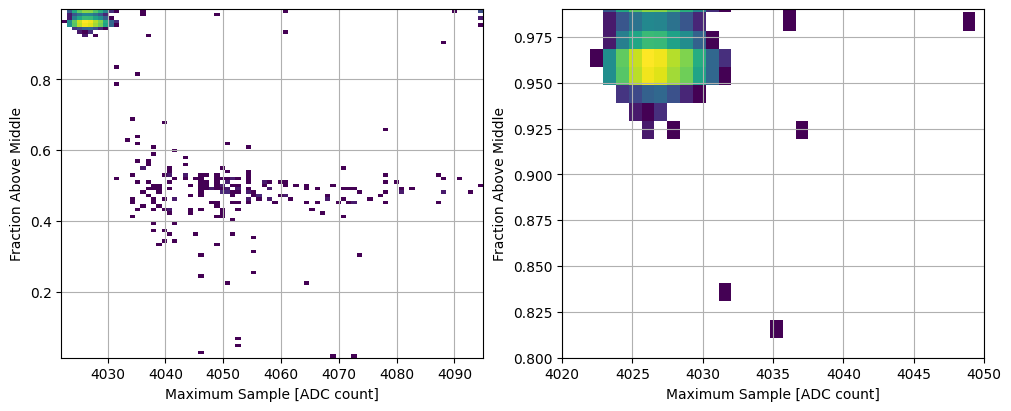

In [7]:
fig, axes = plt.subplots( 1, 2, figsize=(10,4), constrained_layout=True)

axes[0].hist2d( waveform_stat[:,6], waveform_stat[:,8], bins=[80,100], norm=matplotlib.colors.LogNorm());
axes[0].set_ylabel('Fraction Above Middle')
axes[0].set_xlabel('Maximum Sample [ADC count]')
axes[0].grid(True)

axes[1].hist2d( waveform_stat[:,6], waveform_stat[:,8], bins=[80,100], norm=matplotlib.colors.LogNorm());
axes[1].set_xlabel('Maximum Sample [ADC count]')
axes[1].set_ylabel('Fraction Above Middle')
axes[1].grid(True)

axes[1].set_xlim([4020,4050])
axes[1].set_ylim([0.8,0.99])

plt.show()

### Display Outlier Events - Transient Noise

First inspect upper right region - namely high fraction (near baseline, but much higher maximum sample

In [8]:
limits = [4035, 0.91]

mask_bad_events = (waveform_stat[:,6] > limits[0]) | (waveform_stat[:,8] < limits[1])
print( len( waveform_stat[mask_bad_events] ) )

mask = (waveform_stat[:,6] > limits[0]) | (waveform_stat[:,8] < limits[1])

allowed_indices = waveform_stat[mask][:,0]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

243


SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

### Distribution of Standard Deviation of Noise Events

Of the bad events, inspect the std dev of entire waveform and that of pre-trigger window only

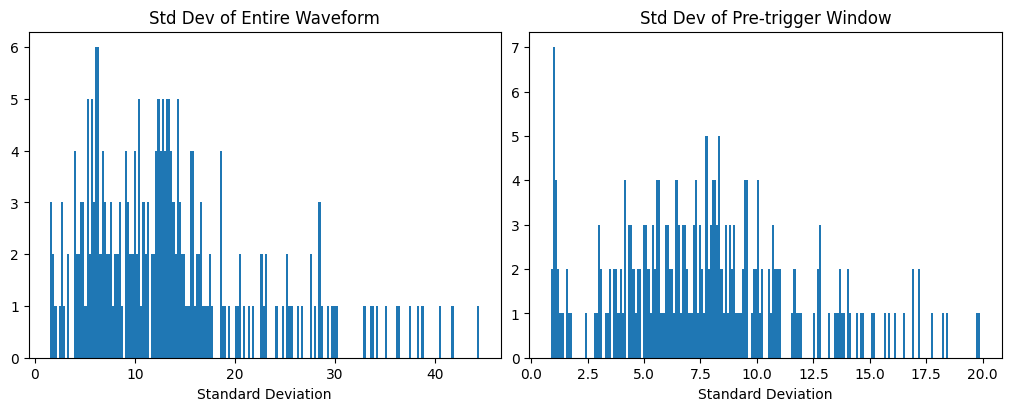

In [9]:
fig, axes = plt.subplots( 1, 2, figsize=(10,4), constrained_layout=True)

axes[0].hist( waveform_stat[mask][:,2], bins=200);
axes[0].set_xlabel("Standard Deviation")
axes[0].set_title("Std Dev of Entire Waveform")

axes[1].hist( waveform_stat[mask][:,4], bins=200);
#axes[1].set_xlim([0,3])
axes[1].set_xlabel("Standard Deviation")
axes[1].set_title("Std Dev of Pre-trigger Window")

plt.show()

### Plot Oscillating Events

These events have a large baseline fluctuation initially, so use a standard deviation threshold of 2.5

In [9]:
std_threshold = 2.5

mask = ( (waveform_stat[:,6] > limits[0]) | (waveform_stat[:,8] < limits[1]) ) & (waveform_stat[:,4] > std_threshold)

allowed_indices = waveform_stat[mask][:,0]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

Noisy events with initially small standard deviation

In [10]:
std_threshold = 2.5

mask = ( (waveform_stat[:,6] > limits[0]) | (waveform_stat[:,8] < limits[1]) ) & (waveform_stat[:,4] < std_threshold)

allowed_indices = waveform_stat[mask][:,0]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

## Plot the Distribution of Pre-trigger Baseline Standard Deviation for Events that Passed Oscillating Waveform Cut

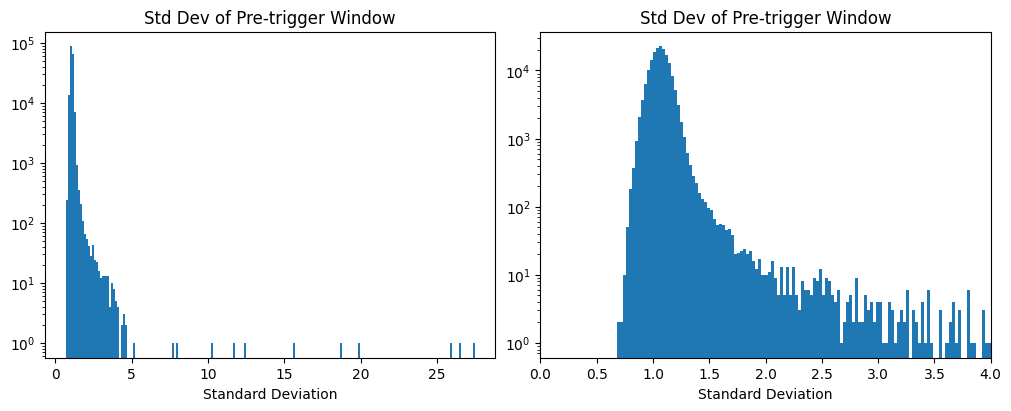

In [47]:
mask = ( (waveform_stat[:,6] < limits[0]) & (waveform_stat[:,8] > limits[1]) )

fig, axes = plt.subplots( 1, 2, figsize=(10,4), constrained_layout=True)

axes[0].hist( waveform_stat[mask][:,4], bins=200);
axes[0].set_yscale('log')
axes[0].set_xlabel("Standard Deviation")
axes[0].set_title("Std Dev of Pre-trigger Window")

axes[1].hist( waveform_stat[mask][:,4], bins=1000);
axes[1].set_xlim([0,4])
axes[1].set_yscale('log')
axes[1].set_xlabel("Standard Deviation")
axes[1].set_title("Std Dev of Pre-trigger Window")

plt.show()

### Inspect Events with Std Larger than 5

In [48]:
std_threshold = 2

mask = ( (waveform_stat[:,6] < limits[0]) & (waveform_stat[:,8] > limits[1]) ) & (waveform_stat[:,4] > std_threshold)

allowed_indices = waveform_stat[mask][:,0]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

### Events with Std Between 4 and 5

In [54]:
std_threshold = [3,4]

mask = ( (waveform_stat[:,6] < limits[0]) & (waveform_stat[:,8] > limits[1]) ) & (waveform_stat[:,4] > std_threshold[0]) & (waveform_stat[:,4] < std_threshold[1])

allowed_indices = waveform_stat[mask][:,0]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

### Conclusion

1. imposing a fraction-above-middle helps reject oscillating noise up and down
2. after cut 1, using pre-trigger baseline standard deviation, one can find partial waveforms for std > 5
3. there are still many events with std between 2 and 5, and these events are due to slow events or those with single photoelectrons in the pre-trigger window

---

# Energy Spectrum After Waveform Quality Cut

In [57]:
def GetBaseline( array, pre_trig_window, n = 10 ):
    '''
    Returns the mean and standard deviation of the pre-trigger baseline
    '''
    avg = np.average( array[:pre_trig_window-n] )
    dev = np.std( array[:pre_trig_window-n] )
    return avg, dev
    

def GetPulseBegin( array, pre_trig_window, nSigma ):
    '''
    Returns the beginning of the pulse, aligned by the first deviation from baseline by N sigmas
    np.where() method returns a tuple with the first element being an array of indices that satisties the condition
    '''
    mean, dev = GetBaseline( array, pre_trig_window)
    arr_len = len(array[:pre_trig_window])
    return np.where( np.abs(array[:pre_trig_window]-mean*np.ones(arr_len) ) < nSigma * dev)[0][-1]

def GetPulseHeightEnergy( array, pre_trig_window, integration_window ):
    
    mean, dev = GetBaseline( array, pre_trig_window )
    
    array =  mean * np.ones( len(array) ) - array
        # get array to be positive polarity
    
    begin = GetPulseBegin( array, pre_trig_window, 1 )
    
    tmp = array[ begin - 4 : begin + integration_window ]

    return np.max(tmp), np.trapezoid(tmp) * 0.004

## Spectrum

To obtain the spectrum, all pulses are processed according to the following rule:
- check for good baseline, if std > 5, skip the event
- find the pulse begin by looking for the last 1-sigma deviation
- integrate from pulse begin - 4 samples for 2 us, and define this for primary pulse
- integrate from the end of the first primary integration window to end of the entire event (define as second event window)

First process all waveforms and record the outputs in a matrix.

Cuts will be applied afterwards.

The output matrix is indexed as following:

1. mean of baseline
2. std of baseline
3. maximum of raw waveform
4. minimum of raw waveform
5. fraction above middle
6. pulse height of ROI
7. integral of ROI
8. height of tail
9. integral of tail
10. timestamp

In [87]:
std_threshold = 5
max_limit = 4035
frac_above_middle = 0.91

In [84]:
counter = 0

event_stat = []
    # result will be array of python tuples

for event_data, event_attr in reader.GetEventIterator():
    
    print( "Processing event {}".format(event_attr["index"]), end='\r' )

    mean, dev = GetBaseline( arr, pre_trigger_window )

    tmp4 = np.max(event_data[channel])
        # maximum ADC count in the entire waveform
    tmp5 = np.min(event_data[channel])
        # minimum ADC count in the entire waveform

    arr = event_data[channel]
    tmp6 = len( arr[ arr > (tmp4+tmp5)/2 ] ) / len(arr)
        # fraction of waveform above the middle of the range
    
    # Now perform baseline subtraction and get energy information
    #        
    array_rev =  mean * np.ones( len(arr) ) - arr
        # use the entire array to calculate mean and fluctuation
    
    begin = GetPulseBegin( array_rev, pre_trigger_window, 1 )
    
    tmp = array_rev[ begin - 4 : begin + 500 ]
    energy1 = np.trapezoid(tmp) * 0.004
    height1 = np.max(tmp)
    
    tmp2 = array_rev[ begin + 500 : ]
    energy2 = np.trapezoid(tmp2) * 0.004
    height2 = np.max(tmp2)

    event_stat.append( [counter,mean,dev,tmp4,tmp5,tmp6,height1,energy1,height2,energy2,event_attr['timestamp']] )

    counter += 1

event_stat = np.array(event_stat)

Processing event 173975

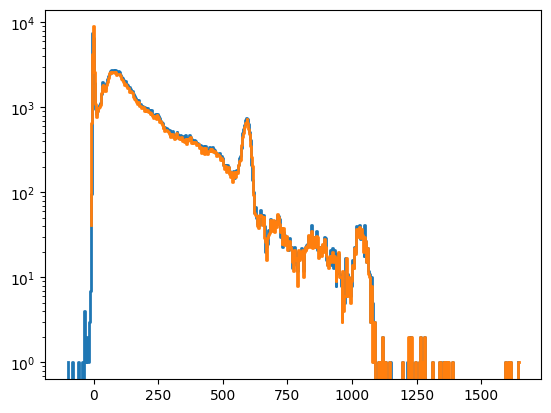

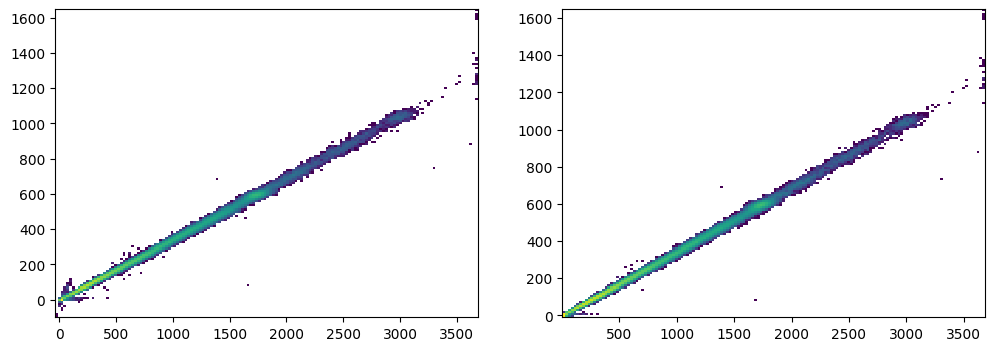

In [92]:
plt.figure()

counts1, bin_edges = np.histogram( event_stat[:,7], bins=500 );
plt.step(bin_edges[:-1], counts1, where='mid', linewidth=2)

cuts = (event_stat[:,3] < max_limit) & (event_stat[:,5] > frac_above_middle) & (event_stat[:,2] < std_threshold) 
counts2, bin_edges = np.histogram( event_stat[cuts][:,7], bins=500 );
plt.step(bin_edges[:-1], counts2, where='mid', linewidth=2)

plt.yscale('log')

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].hist2d( event_stat[:,6], event_stat[:,7], bins=(150,150), norm=matplotlib.colors.LogNorm())
ax[1].hist2d( event_stat[:,6][cuts], event_stat[:,7][cuts], bins=(150,150), norm=matplotlib.colors.LogNorm())
plt.show()

## High-energy region below the main band

This region features same pulse height, but smaller integral.

It turns out to be due to a small pulse succeeded by a bigger pulse (similar to a Bi-Po event).
Due to the way integral is done, pulses getting very close to the primary pulse is integrated into the primary region
if the pulse is more separated, then the main pulse is not entering the primary integral region (500 samples / 2 us)

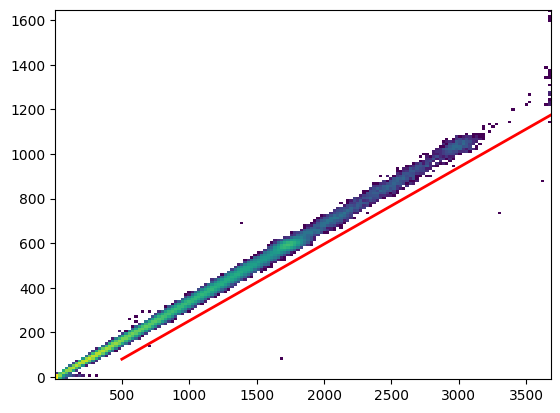

SelectionSlider(continuous_update=False, description='Event:', layout=Layout(width='70%'), options=(np.float64…

Output()

In [100]:
plt.figure()

mask = cuts & (event_stat[:,6] < 4000)

plt.hist2d( event_stat[:,6][mask], event_stat[:,7][mask], bins=(150,150), norm=matplotlib.colors.LogNorm())

def HALE( x ):
    x1, x2 = [500,3000]
    y1, y2 = [80,940]
    return y1 + (y2-y1)/(x2-x1) * (x-x1)
    
def Cut_HALE( x, y ):
    return y - HALE(x) > 0
    
xrange = np.array([500, 4000])
plt.plot( xrange, HALE(xrange), color = 'red', lw = 2 )

plt.show()

mask = cuts & (event_stat[:,6] < 4000) & (event_stat[:,6] > 500) & ( Cut_HALE( event_stat[:,6], event_stat[:,7] )==False )
allowed_indices = event_stat[:,0][mask]

slider = widgets.SelectionSlider(
    options=allowed_indices,
    value=allowed_indices[0],
    description='Event:',
    continuous_update=False,
    layout=widgets.Layout(width='70%'),
    style={'description_width': 'initial'}
)

# Create the output widget to hold the figure
out = widgets.Output()

# Function to update output
def on_slider_change(change):
    with out:
        out.clear_output(wait=True)
        plot_waveform(change['new'])
        print()

# Attach callback
slider.observe(on_slider_change, names='value')

# Display slider and output area
display(slider, out)

In [11]:
reader.Close()